In [2]:
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

In [ ]:
# define biases
A_BIAS = 0.65 # unknown (true bias of A)
B_BIAS = 0.55 # unknown (true bias of B)

# number of coinflips per trial
N = 20

# generate trials
NUM_A_TRIALS = 20 # unknown
NUM_B_TRIALS = 20 # unknown
trials = []

n_heads_A = np.random.binomial(N, A_BIAS, NUM_A_TRIALS)
n_heads_B = np.random.binomial(N, B_BIAS, NUM_B_TRIALS)

print('shape n_head_A:', n_heads_A.shape) # 20
print('shape n_head_B:', n_heads_B.shape) # 20

for i in range(NUM_A_TRIALS):
    # only n_heads value is known, not coin
    trials.append({"n_heads": n_heads_A[i], "coin": "A"})

for i in range(NUM_B_TRIALS):
    # only n_heads value is known, not coin
    trials.append({"n_heads": n_heads_B[i], "coin": "B"})

for i in trials:
    print(i)

shape n_head_A: (20,)
shape n_head_B: (20,)
{'n_heads': np.int32(14), 'coin': 'A'}
{'n_heads': np.int32(11), 'coin': 'A'}
{'n_heads': np.int32(14), 'coin': 'A'}
{'n_heads': np.int32(10), 'coin': 'A'}
{'n_heads': np.int32(10), 'coin': 'A'}
{'n_heads': np.int32(9), 'coin': 'A'}
{'n_heads': np.int32(13), 'coin': 'A'}
{'n_heads': np.int32(9), 'coin': 'A'}
{'n_heads': np.int32(10), 'coin': 'A'}
{'n_heads': np.int32(14), 'coin': 'A'}
{'n_heads': np.int32(15), 'coin': 'A'}
{'n_heads': np.int32(13), 'coin': 'A'}
{'n_heads': np.int32(10), 'coin': 'A'}
{'n_heads': np.int32(9), 'coin': 'A'}
{'n_heads': np.int32(10), 'coin': 'A'}
{'n_heads': np.int32(14), 'coin': 'A'}
{'n_heads': np.int32(11), 'coin': 'A'}
{'n_heads': np.int32(14), 'coin': 'A'}
{'n_heads': np.int32(12), 'coin': 'A'}
{'n_heads': np.int32(13), 'coin': 'A'}
{'n_heads': np.int32(12), 'coin': 'B'}
{'n_heads': np.int32(10), 'coin': 'B'}
{'n_heads': np.int32(15), 'coin': 'B'}
{'n_heads': np.int32(13), 'coin': 'B'}
{'n_heads': np.int32(15

iteration: 0
trial:
{'n_heads': np.int32(14), 'coin': 'A'}
prob A and B norm: 0.6965389854382452 0.3034610145617548
trial:
{'n_heads': np.int32(11), 'coin': 'A'}
prob A and B norm: 0.39550381562684384 0.6044961843731562
trial:
{'n_heads': np.int32(14), 'coin': 'A'}
prob A and B norm: 0.6965389854382452 0.3034610145617548
trial:
{'n_heads': np.int32(10), 'coin': 'A'}
prob A and B norm: 0.30098675372002764 0.6990132462799723
trial:
{'n_heads': np.int32(10), 'coin': 'A'}
prob A and B norm: 0.30098675372002764 0.6990132462799723
trial:
{'n_heads': np.int32(9), 'coin': 'A'}
prob A and B norm: 0.2208066219682617 0.7791933780317384
trial:
{'n_heads': np.int32(13), 'coin': 'A'}
prob A and B norm: 0.6016876841044089 0.39831231589559124
trial:
{'n_heads': np.int32(9), 'coin': 'A'}
prob A and B norm: 0.2208066219682617 0.7791933780317384
trial:
{'n_heads': np.int32(10), 'coin': 'A'}
prob A and B norm: 0.30098675372002764 0.6990132462799723
trial:
{'n_heads': np.int32(14), 'coin': 'A'}
prob A and 

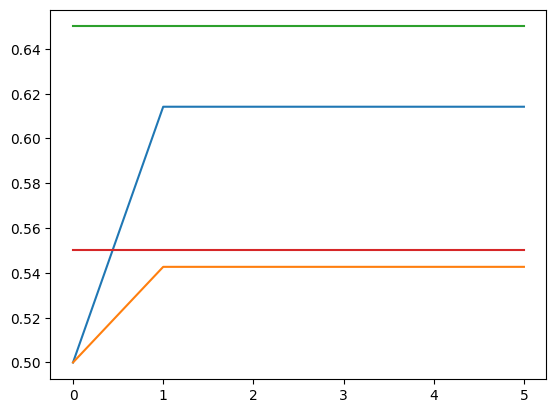

In [4]:
# initialize guesses

# guess bias towards heads
p_A = 0.5
p_B = 0.5

# guesses for which coins generated which trial
coin_guesses = []

N_ITERATIONS = 5

p_A_estimates = [p_A]
p_B_estimates = [p_B]

for i in range(N_ITERATIONS):
    print('iteration:', i)

    p_A_new_N = 0
    p_A_new_D = 0
    p_B_new_N = 0
    p_B_new_D = 0

    # iterate over trials, and compute (normalized) probabilities for coin flips, as
    # well as the new values for p_A and p_B
    for j, t in enumerate(trials):
        print('trial:'); print(t)
        prob_A = binom.pmf(t["n_heads"], N, A_BIAS)
        prob_B = binom.pmf(t["n_heads"], N, B_BIAS)

        prob_A_norm = prob_A / (prob_A + prob_B)
        prob_B_norm = prob_B / (prob_A + prob_B)

        print('prob A and B norm:', prob_A_norm, prob_B_norm)

        p_A_new_N += prob_A_norm * t["n_heads"]
        p_A_new_D += prob_A_norm

        p_B_new_N += prob_B_norm * t["n_heads"]
        p_B_new_D += prob_B_norm

        coin_guesses.append("A" if prob_A > prob_B else "B")

    print()
    
    p_A = p_A_new_N / (p_A_new_D * N)
    p_B = p_B_new_N / (p_B_new_D * N)

    p_A_estimates.append(p_A)
    p_B_estimates.append(p_B)

    print('new estimated biases:', p_A, p_B)

print('coin guesses and correct values:')
c = 0
for k in range(NUM_A_TRIALS + NUM_A_TRIALS):
    print('guessed:', coin_guesses[k], ", correct:", trials[k]["coin"])
    if coin_guesses[k] == trials[k]["coin"]:
        c += 1

print('% correct coin guesses:')
print(c / (NUM_A_TRIALS + NUM_B_TRIALS) * 100, "%")

plt.plot(p_A_estimates)
plt.plot(p_B_estimates)
plt.plot([A_BIAS for _ in range(N_ITERATIONS + 1)])
plt.plot([B_BIAS for _ in range(N_ITERATIONS + 1)])

plt.show()



